In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from tqdm.notebook import tqdm
from IPython.display import clear_output

# Eiffel Tower

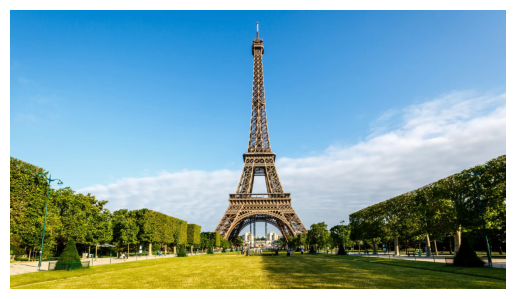

In [3]:
img = mpimg.imread('./eiffel_tower.jpg')

plt.imshow(img)
plt.axis('off')
plt.show()

We will first try to reduce the dimensionality of the grayscale image, and then we will generalize the method to RGB images.

(1440, 2560)
float64


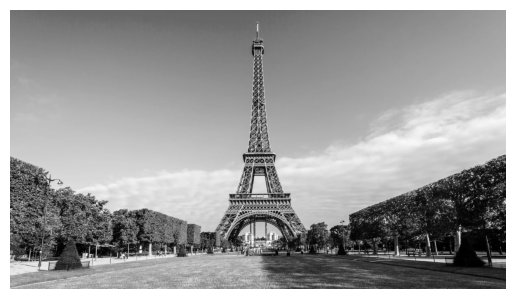

A =  [[114. 115. 115. ... 158. 158. 158.]
 [115. 115. 115. ... 158. 158. 158.]
 [115. 115. 115. ... 158. 158. 158.]
 ...
 [188. 179. 188. ...  51.  48.  49.]
 [172. 168. 185. ...  53.  52.  53.]
 [171. 162. 172. ...  57.  52.  53.]]


In [4]:
img = Image.open('./eiffel_tower.jpg')


img_gray = img.convert('L')  # Convert to grayscale
A = np.array(img_gray) # Store as NumPy array
A = A.astype(np.float64) 

print(A.shape)
print(A.dtype)

plt.imshow(A, cmap='gray')
plt.axis('off')
plt.show()
print('A = ', A)

First we want to create $B = A^T A = V \sum V^T$  

In [5]:
B = A.T @ A

In [6]:
print(B.shape)
print('B = ', B)


(2560, 2560)
B =  [[32640697. 32306047. 31796872. ... 28418372. 28183237. 28108498.]
 [32306047. 32454137. 32049943. ... 28382182. 28146470. 28087382.]
 [31796872. 32049943. 32221916. ... 28398726. 28157261. 28094763.]
 ...
 [28418372. 28382182. 28398726. ... 32373468. 31997907. 31637240.]
 [28183237. 28146470. 28157261. ... 31997907. 31951003. 31628541.]
 [28108498. 28087382. 28094763. ... 31637240. 31628541. 31670435.]]


For efficency in computing the first singular value, we will generate a random unit vector $x \in \mathbb R^{2560}$, with $\|x\| = 1$

In [7]:
x = np.random.randn(2560, 1)
x = x / np.linalg.norm(x)
print(x.shape)
print('x = ', x)

(2560, 1)
x =  [[-0.02314136]
 [ 0.00190395]
 [-0.00501766]
 ...
 [ 0.03466258]
 [-0.01835151]
 [-0.03884932]]


In [8]:
x_prev = x
x_next = B @ x
x_next = x_next / np.linalg.norm(x_next)
step = 0

while np.linalg.norm(x_prev - x_next) > 0.00000001:
    step += 1
    x_prev, x_next = x_next, B @ x_next
    x_next = x_next / np.linalg.norm(x_next)

singular_value_1 = np.sqrt(((B @ x_next) / x_next)[0])

We have $B = A^T \cdot A = V \sum^2 V^T$ and $x \simeq v_1$

Then $Bx = V \sum^2 V^T \cdot v_1 = \sum v_i \cdot \sigma_i^2 \cdot v^T_i \cdot v_1 = \sigma_1^2 \cdot v_1$ 

So $x^T Bx = x^T \cdot \sigma_1^2 \cdot v_1 \simeq \sigma_1^2 \cdot v_1^T v_1 = \sigma_1^2$

But also notice that $x^T B x = x^T A^T \cdot A x = \|Ax\|^2 = \sigma_1^2$


In [9]:
singular_value_1 =  np.linalg.norm(A@x_next)

Now time to compare our singular values for $A$

In [10]:
U, S, Vt = np.linalg.svd(A)
print(abs(singular_value_1 - S[0]))

1.57160684466362e-09


Almost identical

Also compare the singular vectors

In [11]:
print(Vt[0])
print(x_next.flatten())

[0.01859281 0.01850615 0.01847019 ... 0.01740517 0.01717073 0.01711334]
[0.01859281 0.01850615 0.01847019 ... 0.01740517 0.01717073 0.01711334]


In [12]:
U_1 = (1/singular_value_1) * (A @ x_next)

print(U[: , 0])
print(U_1.flatten())

[0.02017352 0.02017768 0.02018078 ... 0.02119566 0.02127327 0.02133514]
[0.02017352 0.02017768 0.02018078 ... 0.02119566 0.02127327 0.02133514]


Below image is the first approximation of our image !!! 

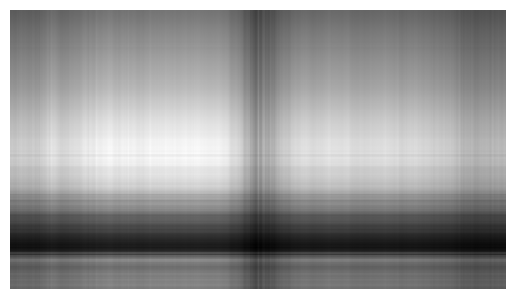

In [13]:
plt.imshow(singular_value_1 * (U_1 @ x_next.T), cmap='gray')
plt.axis('off')
plt.show()

Now we want to generate more singular vectors !!! 

Let's begin

------

(1440, 2560)
float64


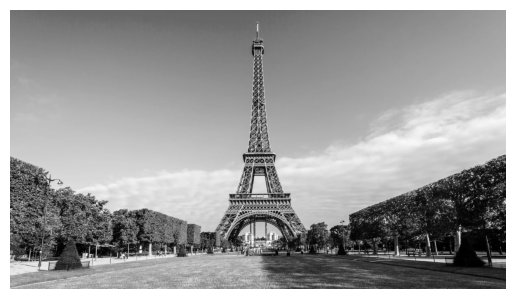

In [14]:
img = Image.open('./eiffel_tower.jpg')


img_gray = img.convert('L')  # Convert to grayscale
A = np.array(img_gray) # Store as NumPy array
A = A.astype(np.float64) 

print(A.shape)
print(A.dtype)

plt.imshow(A, cmap='gray')
plt.axis('off')
plt.show()

In [15]:
def SVD(A, lim = float('inf')):
    B = A.T @ A

    U, S, V = [], [1], []
    min_dim = min(min(A.shape), lim)

    pbar = tqdm(total=min_dim, desc="Computing singular values")

    while S[-1] > 0.00000001 and (len(V) < min_dim):
        pbar.update(1)
        # print(len(V), end = ' ')

        x = np.random.randn(A.shape[1], 1)
        x = x / np.linalg.norm(x)

        x_prev = x
        x_next = B @ x
        x_next = x_next / np.linalg.norm(x_next)
        step = 0

        while np.linalg.norm(x_prev - x_next) > 0.00000001:
            step += 1
            x_prev, x_next = x_next, B @ x_next
            x_next = x_next / np.linalg.norm(x_next)

        singular_value_1 =  np.linalg.norm(A@x_next)
        U_1 = (1/singular_value_1) * (A @ x_next)

        U.append(U_1)
        S.append(singular_value_1)
        V.append(x_next)

        B = B - np.pow(singular_value_1,2) * (x_next @ x_next.T)
    
    pbar.close()

    U = np.array(U)
    U = np.squeeze(U, axis=2).T

    S = np.array(S[1:])
    
    V = np.array(V)
    V = np.squeeze(V, axis=2)
    
    return U, S, V



In [16]:
U,S,V = SVD(A, 200)

Computing singular values:   0%|          | 0/200 [00:00<?, ?it/s]

In [17]:
V_size = V[0, :].shape[0]
V_size

2560

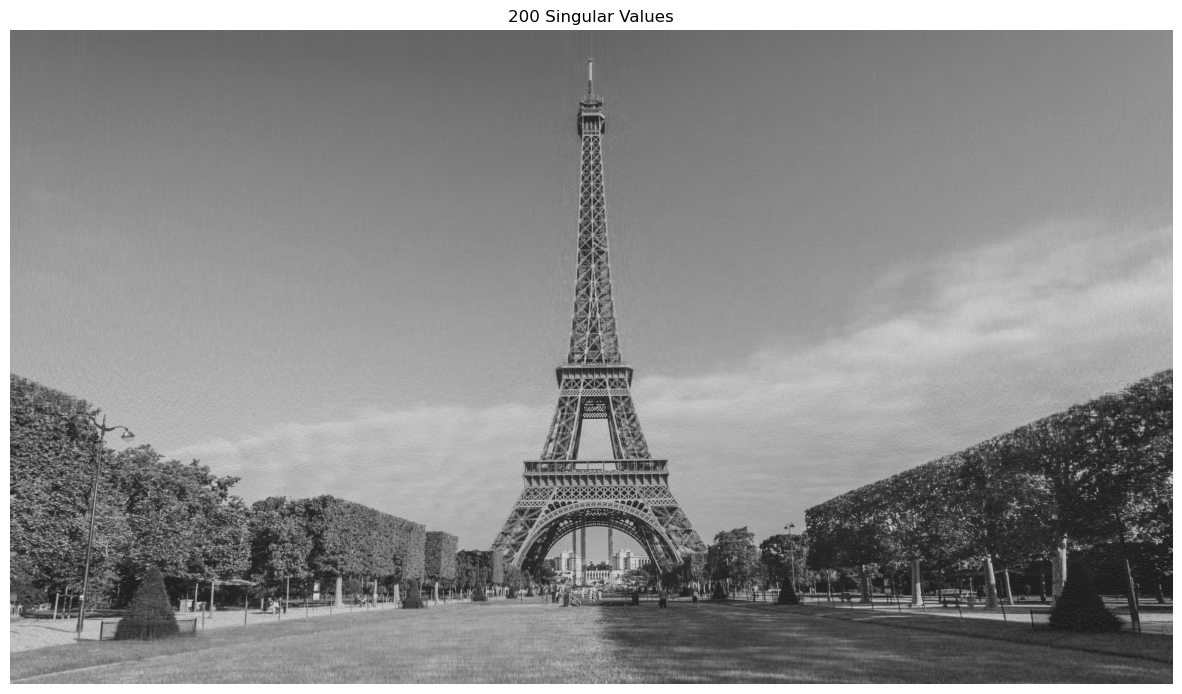

21.60 %


In [18]:
A_k = np.zeros((U.shape[0], V.shape[1]))
U_size = U[:,0].shape[0]
V_size = V[0, :].shape[0]
total_storage = A.size

for k in range(200):

    A_k += S[k] * np.outer(U[:, k], V[k, :])



    clear_output(wait=True)
    plt.figure(figsize=(15, 15))
    plt.imshow(A_k, cmap='gray')
    plt.title(f"{k+1} Singular Values")
    plt.axis('off')
    plt.show()

    SVD_storage = k * (U_size + V_size + 1)
    saved_memory = SVD_storage / total_storage * 100

    print(f'{saved_memory:.2f} %')


    

---------

# RGB 
Now we want to also add for RGB

(1440, 2560, 3)
float64


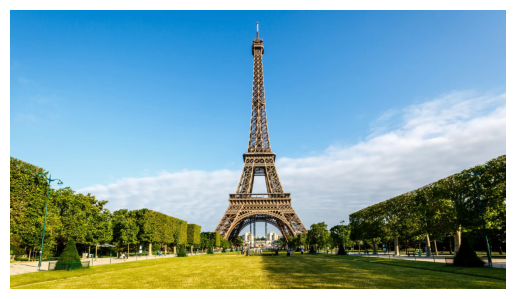

A =  [[139. 140. 140. ... 169. 169. 169.]
 [140. 140. 140. ... 169. 169. 169.]
 [140. 140. 140. ... 169. 169. 169.]
 ...
 [198. 188. 196. ...  62.  59.  60.]
 [183. 178. 194. ...  64.  63.  64.]
 [182. 172. 180. ...  68.  63.  64.]]


In [19]:
img = Image.open('./eiffel_tower.jpg')
A = np.array(img).astype(np.float64)

print(A.shape)
print(A.dtype)

plt.imshow(A.astype(np.uint8))
plt.axis('off')
plt.show()
print('A = ', A[:,:,1])

In [20]:
R = A[:,:,0]
G = A[:,:,1]
B = A[:,:,2]

In [ ]:
U_r, S_r, V_r = SVD(R, lim = 200)
U_g, S_g, V_g = SVD(G, lim = 200)
U_b, S_b, V_b = SVD(B, lim = 200)

Computing singular values:   0%|          | 0/200 [00:00<?, ?it/s]

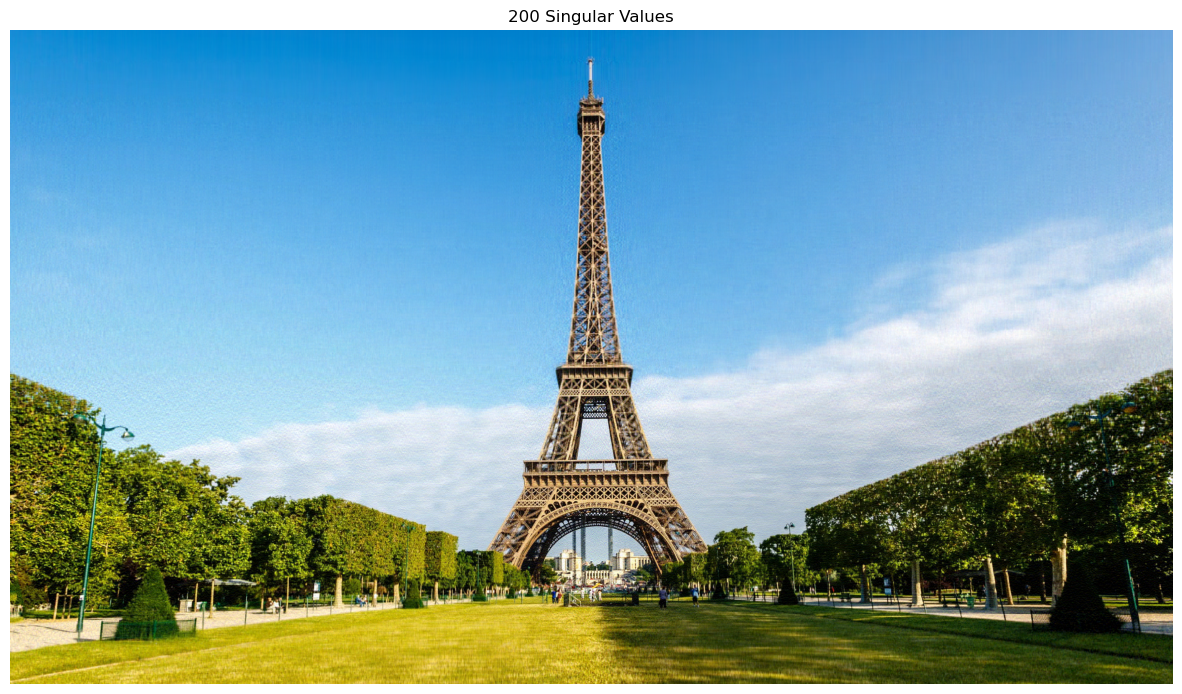

29.32 %


In [ ]:
total_storage = A.size
U_size = U_r[:,0].size
V_size = V_r[0,:].size


R_k = np.zeros((U_r.shape[0], V_r.shape[1]))
G_k = np.zeros((U_g.shape[0], V_g.shape[1]))
B_k = np.zeros((U_b.shape[0], V_b.shape[1]))

for k in range(200):

    R_k += S_r[k] * np.outer(U_r[:, k], V_r[k, :])
    G_k += S_g[k] * np.outer(U_g[:, k], V_g[k, :])
    B_k += S_b[k] * np.outer(U_b[:, k], V_b[k, :])

    clear_output(wait=True)

    A_k = np.stack([R_k, G_k, B_k], axis=2)
    A_k = np.clip(A_k, 0, 255).astype(np.uint8)

    plt.figure(figsize=(15, 15))
    plt.imshow(A_k)
    plt.title(f"{k+1} Singular Values")
    plt.axis('off')
    plt.show()

    Used_storage = k * 3 * (U_size + V_size + 1)
    Saved_storage = Used_storage / total_storage * 100

    print(f'{Saved_storage:.2f} %')



---

# Observing The Singular Values

It is also important to examine the distribution of the singular values, as this plays a key role in determining whether SVD is suitable for dimensionality reduction.

If the singular values are close to one another, then even if they are numerically stable, we cannot reliably identify the corresponding singular vectors.

Since singular vectors are the primary objects used for dimensionality reduction, a lack of separation between singular values can make the resulting low-dimensional representation unstable.

For this reason, we add functionality to visualize the singular values. By examining their distribution, we can better assess the effectiveness and stability of SVD-based dimensionality reduction.

In [ ]:
def SVD(A, lim = float('inf'), plot_singular_values=False):
    A = A.astype(np.float64) 
    B = A.T @ A

    U, S, V = [], [1], []
    min_dim = min(min(A.shape), lim)

    pbar = tqdm(total=min_dim, desc="Computing singular values")

    while S[-1] > 0.00000001 and (len(V) < min_dim):
        pbar.update(1)
        # print(len(V), end = ' ')

        x = np.random.randn(A.shape[1], 1)
        x = x / np.linalg.norm(x)

        x_prev = x
        x_next = B @ x
        x_next = x_next / np.linalg.norm(x_next)
        step = 0

        while np.linalg.norm(x_prev - x_next) > 0.00000001:
            step += 1
            x_prev, x_next = x_next, B @ x_next
            x_next = x_next / np.linalg.norm(x_next)

        singular_value_1 =  np.linalg.norm(A@x_next)
        U_1 = (1/singular_value_1) * (A @ x_next)

        U.append(U_1)
        S.append(singular_value_1)
        V.append(x_next)

        B = B - np.pow(singular_value_1,2) * (x_next @ x_next.T)
    
    pbar.close()

    U = np.array(U)
    U = np.squeeze(U, axis=2).T

    S = np.array(S[1:])
    
    V = np.array(V)
    V = np.squeeze(V, axis=2)

    if plot_singular_values:
        plt.figure(figsize=(8, 5))
        plt.semilogy(range(1, len(S) + 1), S, marker='o')
        plt.xlabel("Index")
        plt.ylabel("Singular value (log scale)")
        plt.title("Singular values")
        plt.grid(True, which="both")
        plt.show()


    
    return U, S, V

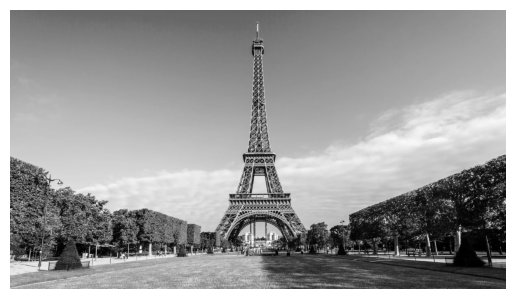

In [ ]:
img = Image.open('./eiffel_tower.jpg')

img_gray = img.convert('L')  # Convert to grayscale

A = np.array(img_gray) # Store as NumPy array
A = A.astype(np.float64) 
plt.imshow(A, cmap='gray')
plt.axis('off')
plt.show()

Computing singular values:   0%|          | 0/20 [00:00<?, ?it/s]

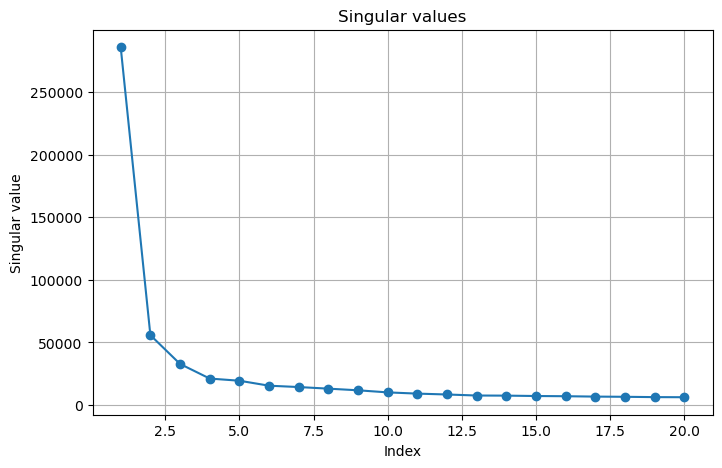

In [ ]:
U,S,V = SVD(A, lim = 20, plot_singular_values = True)

--------

# Adaptation for Multiple Channels

We also want our SVD function to adapt to matrices with multiple channels. For example, for RGB images, we previously had to separate the red, green, and blue channels and apply SVD to each channel individually.

Now, we want our function to automatically adjust to the structure of the input matrix, handling both grayscale and multi-channel images without requiring manual channel separation.

In [ ]:
def channel_SVD(A, lim=float('inf'), plot_singular_values=False):
    A = A.astype(np.float64)

    if A.ndim != 3:
        raise ValueError("Input must have shape (n, m, d).")

    U_channels = []
    S_channels = []
    V_channels = []

    for c in range(A.shape[2]):
        print(f"Computing SVD for channel {c+1}/{A.shape[2]}")

        U_c, S_c, V_c = SVD(
            A[:, :, c],
            lim=lim,
            plot_singular_values=plot_singular_values
        )

        U_channels.append(U_c)
        S_channels.append(S_c)
        V_channels.append(V_c)

    U = np.stack(U_channels, axis=2)
    S = np.stack(S_channels, axis=1)
    V = np.stack(V_channels, axis=2)

    return U, S, V

Time to test it 

(1358, 2000, 3)
float64


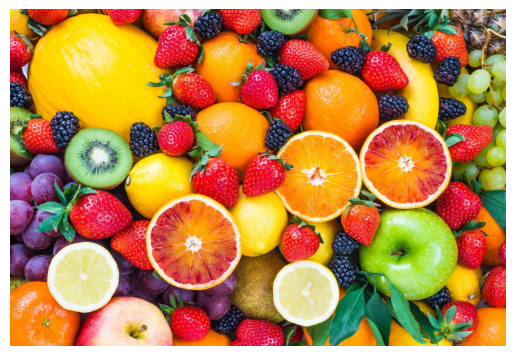

In [ ]:
img = Image.open('./Fruit.png')
A = np.array(img).astype(np.float64)

print(A.shape)
print(A.dtype)

plt.imshow(A.astype(np.uint8))
plt.axis('off')
plt.show()

Computing SVD for channel 1/3


Computing singular values:   0%|          | 0/200 [00:00<?, ?it/s]

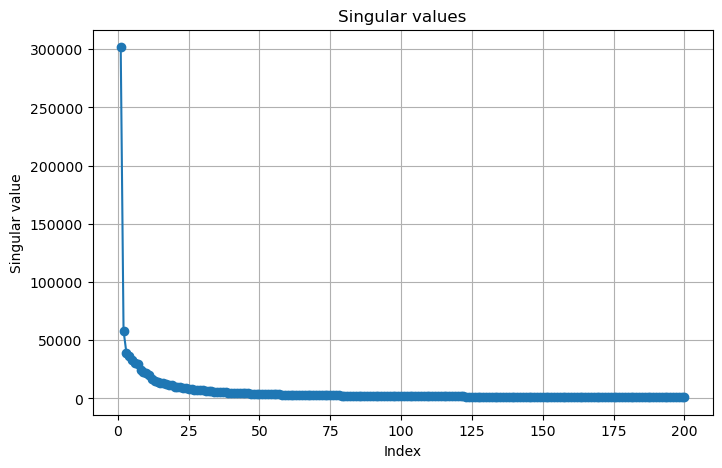

Computing SVD for channel 2/3


Computing singular values:   0%|          | 0/200 [00:00<?, ?it/s]

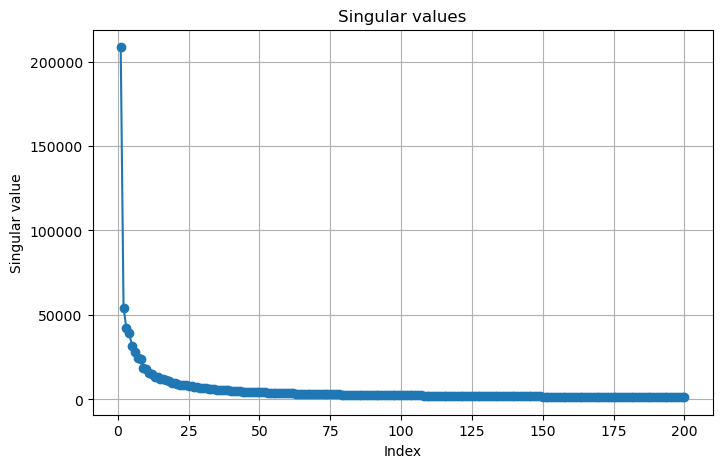

Computing SVD for channel 3/3


Computing singular values:   0%|          | 0/200 [00:00<?, ?it/s]

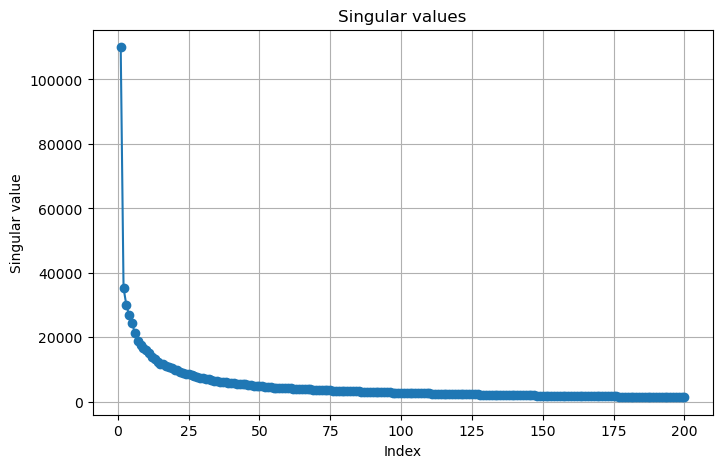

In [ ]:
U,S,V = channel_SVD(A, lim=200, plot_singular_values=True)

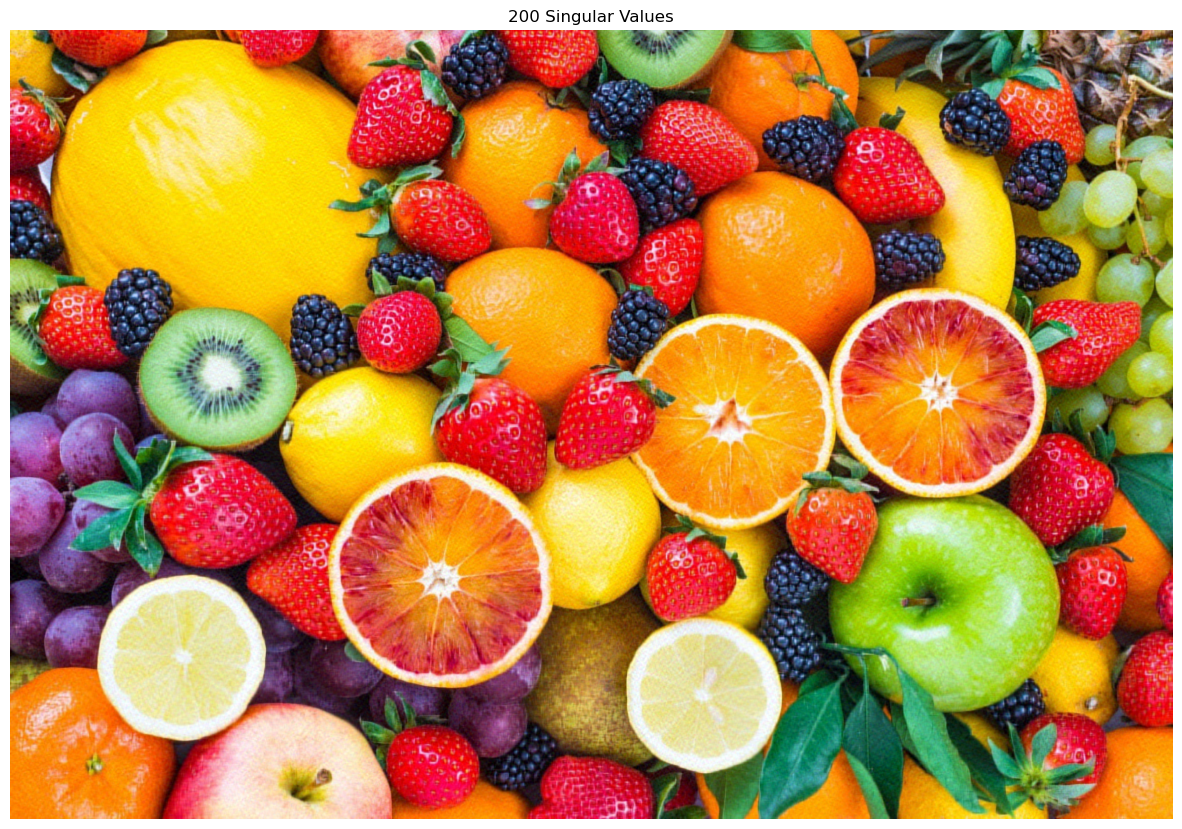

24.61 %


In [ ]:
A_k = np.zeros((U.shape[0], V.shape[1], U.shape[2]))
total_storage = A.size

U_size = U[:,0,0].size
V_size = V[0,:,0].size


for k in range(200):

    for c in reversed(range(U.shape[2])):
        A_k[:, :, c] += S[k, c] * np.outer(U[:, k, c], V[k, :, c])

    clear_output(wait=True)
    A_show = np.clip(A_k, 0, 255).astype(np.uint8)
    plt.figure(figsize=(15, 15))
    plt.imshow(A_show)
    plt.title(f"{k+1} Singular Values")
    plt.axis('off')
    plt.show()

    Used_storage = k * 3 * (U_size + V_size + 1)
    Saved_storage = Used_storage / total_storage * 100
    print(f'{Saved_storage:.2f} %')
